In [1]:
# Step 1: Import necessary libraries and modules
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv1D, MaxPooling1D, Dropout,
                                     GRU, LSTM, Bidirectional, Dense,
                                     GlobalAveragePooling1D, Multiply, Lambda)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Step 2: Load dataset from local CSV
heart_disease_df = pd.read_csv("heart.csv")  # change filename if needed

# Step 3: Preprocess the dataset
# 1. Fill missing values for numeric columns
heart_disease_df = heart_disease_df.fillna(heart_disease_df.mean(numeric_only=True))

# 2. Convert string/object columns to categorical codes
for col in heart_disease_df.select_dtypes(include=['object', 'category']).columns:
    heart_disease_df[col] = heart_disease_df[col].astype('category').cat.codes

# Identify features and target
X = heart_disease_df.drop(columns=['target']) if 'target' in heart_disease_df.columns else heart_disease_df.drop(columns=['class'])
y = heart_disease_df['target'] if 'target' in heart_disease_df.columns else heart_disease_df['class']

# Ensure binary classification (convert to 0 and 1)
if y.nunique() > 2:
    y = (y == y.max()).astype(int)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Step 7: Attention layer function
def create_attention_layer(inputs):
    attention = Dense(1, activation='tanh')(inputs)
    attention = Lambda(lambda x: K.softmax(x, axis=1))(attention)
    weighted_input = Multiply()([inputs, attention])
    return weighted_input

# Step 4-8: Build the CardioNet-X hybrid model
def build_cardionet_x(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = MaxPooling1D(pool_size=2)(x)
    x = Dropout(0.2)(x)
    x = Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
    x = Dropout(0.2)(x)
    x = GRU(units=128, return_sequences=True, dropout=0.2)(x)
    x = Bidirectional(LSTM(units=128, return_sequences=True, dropout=0.2))(x)
    x = create_attention_layer(x)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    return model

# Step 9: Train the model
input_shape = (X_train.shape[1], 1)
model = build_cardionet_x(input_shape)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(X_train, y_train,
          validation_data=(X_test, y_test),
          epochs=100,
          batch_size=32,
          verbose=1)

# Step 10: Generate predictions and evaluate
final_predictions_prob = model.predict(X_test)
final_predictions = (final_predictions_prob > 0.5).astype(int).flatten()

accuracy = accuracy_score(y_test, final_predictions)
report = classification_report(y_test, final_predictions)

# Output results
print(f"Test Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print("\nClassification Report:")
print(report)

# Return results as variables (optional)
# final_predictions, accuracy, report


Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.4916 - loss: 0.6930 - val_accuracy: 0.5707 - val_loss: 0.6892
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5663 - loss: 0.6836 - val_accuracy: 0.6878 - val_loss: 0.6406
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6808 - loss: 0.6141 - val_accuracy: 0.7415 - val_loss: 0.5415
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6995 - loss: 0.5922 - val_accuracy: 0.7756 - val_loss: 0.5184
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7506 - loss: 0.5311 - val_accuracy: 0.8049 - val_loss: 0.4552
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7910 - loss: 0.4823 - val_accuracy: 0.8293 - val_loss: 0.4058
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8097 - loss: 0.4566 - val_accuracy: 0.8390 - val_loss: 0.3958
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8236 - loss: 0.4164 - val_accuracy: 

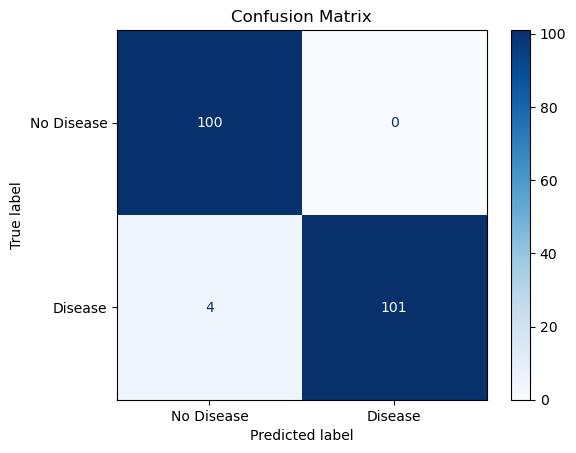

In [2]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, final_predictions)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


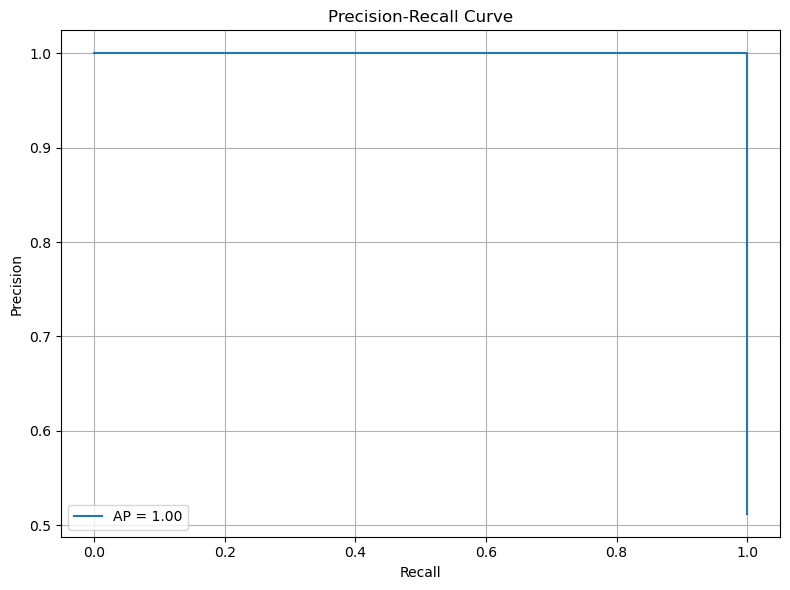

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

# Compute precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, final_predictions_prob)

# Compute average precision score
avg_precision = average_precision_score(y_test, final_predictions_prob)

# Plotting the Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


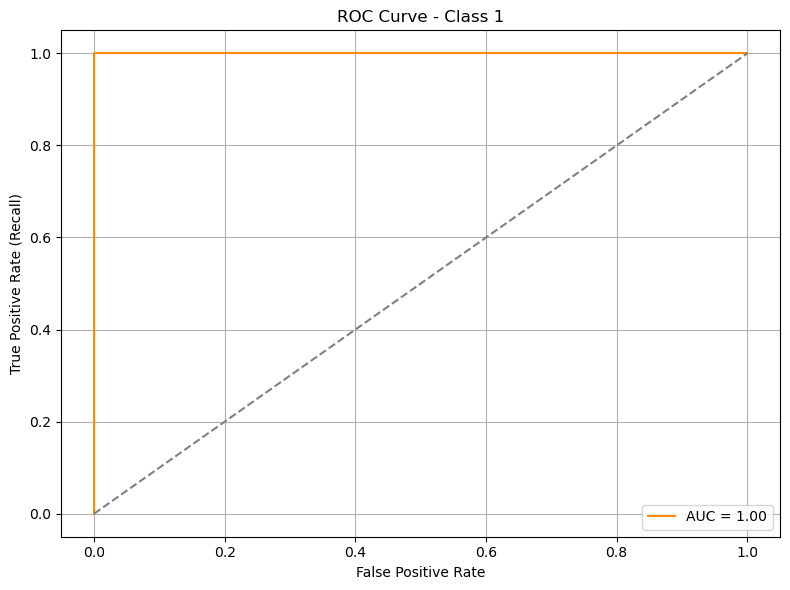

In [4]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Compute ROC curve and AUC score
fpr, tpr, thresholds = roc_curve(y_test, final_predictions_prob)
roc_auc = roc_auc_score(y_test, final_predictions_prob)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Class 1')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()
